# ISMN Network Availability From Site Metadata

This notebook reads ISMN site metadata and reports:

1. All available networks in the local ISMN collection.
2. Earliest and latest available data timestamps per network (from metadata `timerange_from` / `timerange_to`).

It uses the metadata CSV generated by `ISMN_Interface` at:
`/Users/amfox/Desktop/ISMN_data/python_metadata/ISMN_data.csv`


In [28]:
from pathlib import Path
import csv
from datetime import datetime


In [29]:
ISMN_ROOT = Path('/Users/amfox/Desktop/ISMN_data')
METADATA_CSV = ISMN_ROOT / 'python_metadata' / 'ISMN_data.csv'

if not METADATA_CSV.exists():
    raise FileNotFoundError(
        f'Metadata CSV not found: {METADATA_CSV}\n'
        'Initialize ISMN_Interface once for this dataset to generate python_metadata/ISMN_data.csv.'
    )

METADATA_CSV


PosixPath('/Users/amfox/Desktop/ISMN_data/python_metadata/ISMN_data.csv')

In [30]:
def parse_metadata_datetime(value: str):
    if value is None:
        return None

    text = str(value).strip()
    if text == '' or text.lower() in {'nan', 'none', 'nat'}:
        return None

    # Common ISMN metadata datetime formats.
    for fmt in (
        '%Y-%m-%d %H:%M:%S',
        '%Y-%m-%d %H:%M:%S.%f',
        '%Y-%m-%dT%H:%M:%S',
        '%Y-%m-%dT%H:%M:%S.%f',
    ):
        try:
            return datetime.strptime(text, fmt)
        except ValueError:
            continue

    return None

def parse_metadata_float(value):
    if value is None:
        return None

    text = str(value).strip()
    if text == '' or text.lower() in {'nan', 'none', 'nat'}:
        return None

    try:
        return float(text)
    except ValueError:
        return None


In [31]:
# Read MultiIndex-header CSV and aggregate by network and station.
network_stats = {}
station_stats = {}

total_rows = 0
valid_from_count = 0
valid_to_count = 0

with METADATA_CSV.open(newline='') as f:
    reader = csv.reader(f)
    header_top = next(reader)
    header_sub = next(reader)
    columns = list(zip(header_top, header_sub))
    col_idx = {col: i for i, col in enumerate(columns)}

    required = [
        ('network', 'val'),
        ('station', 'val'),
        ('timerange_from', 'val'),
        ('timerange_to', 'val'),
        ('latitude', 'val'),
        ('longitude', 'val'),
    ]

    missing = [col for col in required if col not in col_idx]
    if missing:
        raise KeyError(f'Missing required metadata columns: {missing}')

    for row in reader:
        total_rows += 1

        network = row[col_idx[('network', 'val')]].strip()
        station = row[col_idx[('station', 'val')]].strip()
        dt_from = parse_metadata_datetime(row[col_idx[('timerange_from', 'val')]])
        dt_to = parse_metadata_datetime(row[col_idx[('timerange_to', 'val')]])
        latitude = parse_metadata_float(row[col_idx[('latitude', 'val')]])
        longitude = parse_metadata_float(row[col_idx[('longitude', 'val')]])

        if dt_from is not None:
            valid_from_count += 1
        if dt_to is not None:
            valid_to_count += 1

        if network not in network_stats:
            network_stats[network] = {
                'n_metadata_rows': 0,
                'stations': set(),
                'earliest_data': None,
                'latest_data': None,
            }

        net_stats = network_stats[network]
        net_stats['n_metadata_rows'] += 1

        if station:
            net_stats['stations'].add(station)

        if dt_from is not None and (net_stats['earliest_data'] is None or dt_from < net_stats['earliest_data']):
            net_stats['earliest_data'] = dt_from

        if dt_to is not None and (net_stats['latest_data'] is None or dt_to > net_stats['latest_data']):
            net_stats['latest_data'] = dt_to

        station_key = (network, station)
        if station_key not in station_stats:
            station_stats[station_key] = {
                'n_metadata_rows': 0,
                'earliest_data': None,
                'latest_data': None,
                'latitude': None,
                'longitude': None,
            }

        stn_stats = station_stats[station_key]
        stn_stats['n_metadata_rows'] += 1

        if stn_stats['latitude'] is None and latitude is not None:
            stn_stats['latitude'] = latitude

        if stn_stats['longitude'] is None and longitude is not None:
            stn_stats['longitude'] = longitude

        if dt_from is not None and (stn_stats['earliest_data'] is None or dt_from < stn_stats['earliest_data']):
            stn_stats['earliest_data'] = dt_from

        if dt_to is not None and (stn_stats['latest_data'] is None or dt_to > stn_stats['latest_data']):
            stn_stats['latest_data'] = dt_to

summary_rows = []
for network in sorted(network_stats):
    stats = network_stats[network]
    earliest = stats['earliest_data']
    latest = stats['latest_data']
    coverage_days = (latest - earliest).days if earliest is not None and latest is not None else None

    summary_rows.append(
        {
            'network': network,
            'n_metadata_rows': stats['n_metadata_rows'],
            'n_stations': len(stats['stations']),
            'earliest_data': earliest,
            'latest_data': latest,
            'coverage_days': coverage_days,
        }
    )

station_summary_rows = []
for (network, station), stats in sorted(station_stats.items()):
    earliest = stats['earliest_data']
    latest = stats['latest_data']
    coverage_days = (latest - earliest).days if earliest is not None and latest is not None else None

    station_summary_rows.append(
        {
            'network': network,
            'station': station,
            'n_metadata_rows': stats['n_metadata_rows'],
            'earliest_data': earliest,
            'latest_data': latest,
            'coverage_days': coverage_days,
            'latitude': stats['latitude'],
            'longitude': stats['longitude'],
        }
    )

print(f'Read {total_rows:,} metadata rows from {METADATA_CSV}')
print(f'Rows with valid timerange_from: {valid_from_count:,}')
print(f'Rows with valid timerange_to:   {valid_to_count:,}')
print(f'Unique networks found:         {len(summary_rows):,}')
print(f'Unique stations found:         {len(station_summary_rows):,}')

summary_rows[:5]


Read 34,797 metadata rows from /Users/amfox/Desktop/ISMN_data/python_metadata/ISMN_data.csv
Rows with valid timerange_from: 34,797
Rows with valid timerange_to:   34,797
Unique networks found:         88
Unique stations found:         3,279


[{'network': 'AACES',
  'n_metadata_rows': 244,
  'n_stations': 49,
  'earliest_data': datetime.datetime(2005, 5, 9, 13, 0),
  'latest_data': datetime.datetime(2010, 9, 24, 1, 0),
  'coverage_days': 1963},
 {'network': 'AMMA-CATCH',
  'n_metadata_rows': 37,
  'n_stations': 7,
  'earliest_data': datetime.datetime(2006, 1, 1, 0, 0),
  'latest_data': datetime.datetime(2018, 12, 31, 23, 0),
  'coverage_days': 4747},
 {'network': 'ARM',
  'n_metadata_rows': 1226,
  'n_stations': 35,
  'earliest_data': datetime.datetime(1993, 6, 29, 13, 0),
  'latest_data': datetime.datetime(2026, 2, 9, 0, 0),
  'coverage_days': 11912},
 {'network': 'AWDN',
  'n_metadata_rows': 232,
  'n_stations': 50,
  'earliest_data': datetime.datetime(1997, 12, 31, 17, 0),
  'latest_data': datetime.datetime(2010, 12, 30, 17, 0),
  'coverage_days': 4747},
 {'network': 'BDF_Saxony',
  'n_metadata_rows': 43,
  'n_stations': 4,
  'earliest_data': datetime.datetime(1996, 6, 20, 9, 0),
  'latest_data': datetime.datetime(2025, 

In [32]:
# Print network summary table (sorted by network).
headers = ['network', 'n_metadata_rows', 'n_stations', 'earliest_data', 'latest_data', 'coverage_days']

widths = {
    'network': max(len('network'), max(len(str(r['network'])) for r in summary_rows)),
    'n_metadata_rows': len('n_metadata_rows'),
    'n_stations': len('n_stations'),
    'earliest_data': len('earliest_data'),
    'latest_data': len('latest_data'),
    'coverage_days': len('coverage_days'),
}

line = (
    f"{headers[0]:<{widths['network']}}  "
    f"{headers[1]:>{widths['n_metadata_rows']}}  "
    f"{headers[2]:>{widths['n_stations']}}  "
    f"{headers[3]:>{widths['earliest_data']}}  "
    f"{headers[4]:>{widths['latest_data']}}  "
    f"{headers[5]:>{widths['coverage_days']}}"
)
print(line)
print('-' * len(line))

for r in summary_rows:
    earliest = r['earliest_data'].isoformat(sep=' ') if r['earliest_data'] is not None else ''
    latest = r['latest_data'].isoformat(sep=' ') if r['latest_data'] is not None else ''
    print(
        f"{str(r['network']):<{widths['network']}}  "
        f"{r['n_metadata_rows']:>{widths['n_metadata_rows']},}  "
        f"{r['n_stations']:>{widths['n_stations']},}  "
        f"{earliest:>{widths['earliest_data']}}  "
        f"{latest:>{widths['latest_data']}}  "
        f"{'' if r['coverage_days'] is None else r['coverage_days']:>{widths['coverage_days']}}"
    )


network             n_metadata_rows  n_stations  earliest_data  latest_data  coverage_days
------------------------------------------------------------------------------------------
AACES                           244          49  2005-05-09 13:00:00  2010-09-24 01:00:00           1963
AMMA-CATCH                       37           7  2006-01-01 00:00:00  2018-12-31 23:00:00           4747
ARM                           1,226          35  1993-06-29 13:00:00  2026-02-09 00:00:00          11912
AWDN                            232          50  1997-12-31 17:00:00  2010-12-30 17:00:00           4747
BDF_Saxony                       43           4  1996-06-20 09:00:00  2025-08-01 03:00:00          10633
BFG_Nw                           15           1  1986-10-31 23:00:00  2026-02-13 06:00:00          14349
BIEBRZA_S-1                     162          27  2015-04-23 20:00:00  2018-12-01 00:00:00           1317
BNZ-LTER                        174          12  1988-06-01 15:00:00  2013-01-01 00

In [33]:
# Simple network list.
available_networks = [row['network'] for row in summary_rows if str(row['network']).strip()]

print(f'Found {len(available_networks)} networks:')
for net in available_networks:
    print(f' - {net}')


Found 88 networks:
 - AACES
 - AMMA-CATCH
 - ARM
 - AWDN
 - BDF_Saxony
 - BFG_Nw
 - BIEBRZA_S-1
 - BNZ-LTER
 - Berlin
 - CALABRIA
 - CAMPANIA
 - CHINA
 - COSMOS
 - COSMOS-UK
 - CTP_SMTMN
 - CW3E
 - DAHRA
 - DWD
 - FLUXNET-AMERIFLUX
 - FMI
 - FR_Aqui
 - GROW
 - GTK
 - HOAL
 - HOBE
 - HSC_SEOLMACHEON
 - HYDROL-NET_PERUGIA
 - HiWATER_EHWSN
 - ICN
 - IIT_KANPUR
 - IMA_CAN1
 - IOWA
 - IPE
 - KHOREZM
 - KIHS_CMC
 - KIHS_SMC
 - LAB-net
 - LABFLUX
 - MAQU
 - METEROBS
 - MOL-RAO
 - MONGOLIA
 - MySMNet
 - NAQU
 - NGARI
 - NVE
 - ORACLE
 - OZNET
 - PBO_H2O
 - PTSMN
 - REMEDHUS
 - RISMA
 - ROMPS
 - RSMN
 - RU-ADDFerti
 - RUSWET-AGRO
 - RUSWET-GRASS
 - RUSWET-VALDAI
 - Ru_CFR
 - SASMAS
 - SCAN
 - SD_DEM
 - SKKU
 - SMN-SDR
 - SMOSMANIA
 - SNOTEL
 - SOILSCAPE
 - SONTE-China
 - STEMS
 - SW-WHU
 - SWEX_POLAND
 - TAHMO
 - TERENO
 - TWENTE
 - TxSON
 - UDC_SMOS
 - UMBRIA
 - UMSUOL
 - USCRN
 - USDA-ARS
 - VAS
 - VDS
 - WATERLINE
 - WEGENERNET
 - WIT-Network
 - WSMN
 - XMS-CAT
 - iRON


In [34]:
# Optional: write summary to CSV in the ISMN notebooks folder.
out_csv = Path('/Users/amfox/Desktop/geosldas-analysis/projects/ISMN/notebooks/ismn_network_timerange_summary.csv')

with out_csv.open('w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['network', 'n_metadata_rows', 'n_stations', 'earliest_data', 'latest_data', 'coverage_days'])
    for r in summary_rows:
        writer.writerow(
            [
                r['network'],
                r['n_metadata_rows'],
                r['n_stations'],
                r['earliest_data'].isoformat(sep=' ') if r['earliest_data'] is not None else '',
                r['latest_data'].isoformat(sep=' ') if r['latest_data'] is not None else '',
                r['coverage_days'] if r['coverage_days'] is not None else '',
            ]
        )

print(f'Wrote: {out_csv}')


Wrote: /Users/amfox/Desktop/geosldas-analysis/projects/ISMN/notebooks/ismn_network_timerange_summary.csv


In [ ]:
# Sites spanning from 2008 to at least 2021.
# Criterion:
# - earliest_data year <= 2008
# - latest_data year >= 2021
qualifying_sites = [
    row for row in station_summary_rows
    if row['earliest_data'] is not None
    and row['latest_data'] is not None
    and row['earliest_data'].year <= 2008
    and row['latest_data'].year >= 2021
]

print('Criterion: earliest_data year <= 2008 and latest_data year >= 2021')
print(f'n qualifying sites: {len(qualifying_sites):,}')

if qualifying_sites:
    # Optional network-level counts for quick context.
    counts_by_network = {}
    for row in qualifying_sites:
        counts_by_network[row['network']] = counts_by_network.get(row['network'], 0) + 1

    print()
    print('Counts by network (qualifying sites):')
    for net, n in sorted(counts_by_network.items(), key=lambda x: (-x[1], x[0])):
        print(f' - {net}: {n}')

    print()
    print('Qualifying sites and actual available dates:')
    header = f"{'network':<18}  {'station':<34}  {'earliest_data':<19}  {'latest_data':<19}  {'n_metadata_rows':>15}"
    print(header)
    print('-' * len(header))
    for row in qualifying_sites:
        print(
            f"{str(row['network']):<18}  "
            f"{str(row['station']):<34}  "
            f"{row['earliest_data'].isoformat(sep=' '):<19}  "
            f"{row['latest_data'].isoformat(sep=' '):<19}  "
            f"{row['n_metadata_rows']:>15,}"
        )
else:
    print('No sites matched this criterion.')


Criterion: earliest_data year <= 2008 and latest_data year >= 2021
n qualifying sites: 604

Counts by network (qualifying sites):
 - SNOTEL: 277
 - SCAN: 138
 - USCRN: 112
 - SMOSMANIA: 20
 - REMEDHUS: 16
 - OZNET: 15
 - WEGENERNET: 13
 - ARM: 6
 - BDF_Saxony: 3
 - BFG_Nw: 1
 - FMI: 1
 - NVE: 1
 - ROMPS: 1

Qualifying sites and actual available dates:
network             station                             earliest_data        latest_data          n_metadata_rows
-----------------------------------------------------------------------------------------------------------------
ARM                 Ashton                              1993-06-29 13:00:00  2023-09-29 12:00:00               61
ARM                 Byron                               1995-06-28 00:00:00  2023-09-29 12:00:00               61
ARM                 Lamont-CF1                          1996-02-05 00:00:00  2026-02-09 00:00:00               58
ARM                 Pawhuska                            1996-07-13 08:00:00 

In [36]:
# Sites spanning from 2000 to at least 2021.
# Criterion:
# - earliest_data year <= 2000
# - latest_data year >= 2021
qualifying_sites_2000 = [
    row for row in station_summary_rows
    if row['earliest_data'] is not None
    and row['latest_data'] is not None
    and row['earliest_data'].year <= 2000
    and row['latest_data'].year >= 2021
]

print('Criterion: earliest_data year <= 2000 and latest_data year >= 2021')
print(f'n qualifying sites: {len(qualifying_sites_2000):,}')

if qualifying_sites_2000:
    counts_by_network_2000 = {}
    for row in qualifying_sites_2000:
        counts_by_network_2000[row['network']] = counts_by_network_2000.get(row['network'], 0) + 1

    print()
    print('Counts by network (qualifying sites):')
    for net, n in sorted(counts_by_network_2000.items(), key=lambda x: (-x[1], x[0])):
        print(f' - {net}: {n}')

    print()
    print('Qualifying sites and actual available dates:')
    header = f"{'network':<18}  {'station':<34}  {'earliest_data':<19}  {'latest_data':<19}  {'n_metadata_rows':>15}"
    print(header)
    print('-' * len(header))
    for row in qualifying_sites_2000:
        print(
            f"{str(row['network']):<18}  "
            f"{str(row['station']):<34}  "
            f"{row['earliest_data'].isoformat(sep=' '):<19}  "
            f"{row['latest_data'].isoformat(sep=' '):<19}  "
            f"{row['n_metadata_rows']:>15,}"
        )
else:
    print('No sites matched this criterion.')


Criterion: earliest_data year <= 2000 and latest_data year >= 2021
n qualifying sites: 62

Counts by network (qualifying sites):
 - SCAN: 38
 - SNOTEL: 12
 - ARM: 6
 - BDF_Saxony: 2
 - USCRN: 2
 - BFG_Nw: 1
 - ROMPS: 1

Qualifying sites and actual available dates:
network             station                             earliest_data        latest_data          n_metadata_rows
-----------------------------------------------------------------------------------------------------------------
ARM                 Ashton                              1993-06-29 13:00:00  2023-09-29 12:00:00               61
ARM                 Byron                               1995-06-28 00:00:00  2023-09-29 12:00:00               61
ARM                 Lamont-CF1                          1996-02-05 00:00:00  2026-02-09 00:00:00               58
ARM                 Pawhuska                            1996-07-13 08:00:00  2026-02-09 00:00:00               59
ARM                 Ringwood                       

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_40757/580060350.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(nets))
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


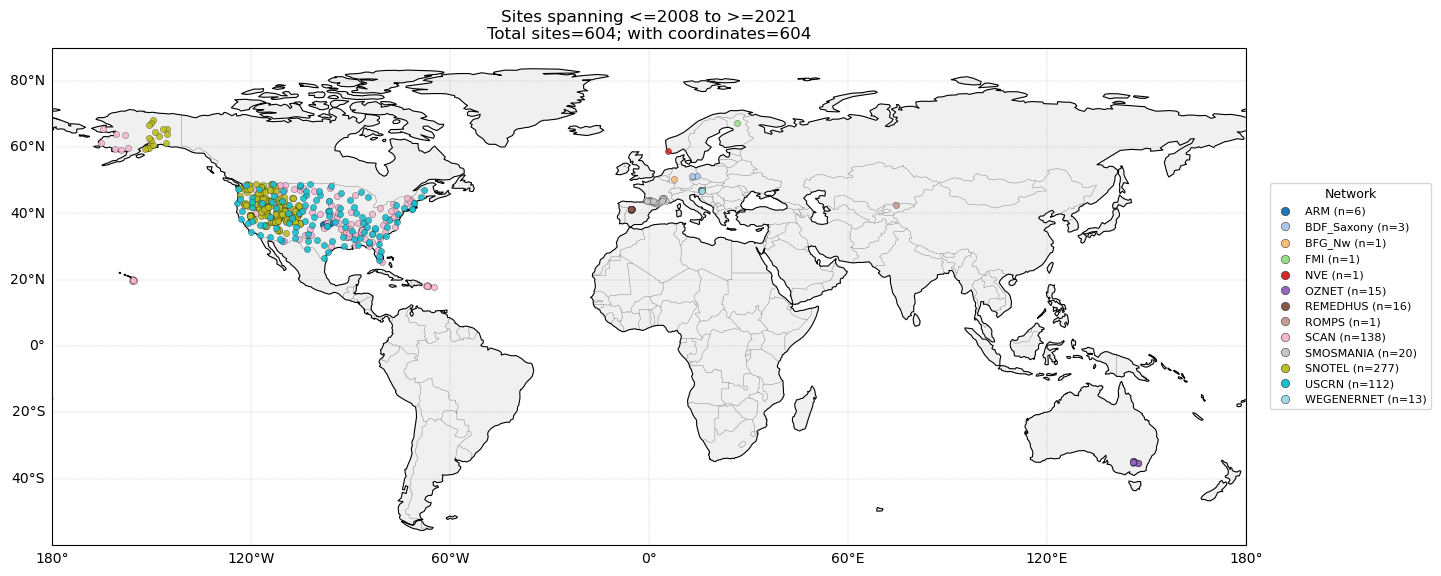

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_40757/580060350.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(nets))
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


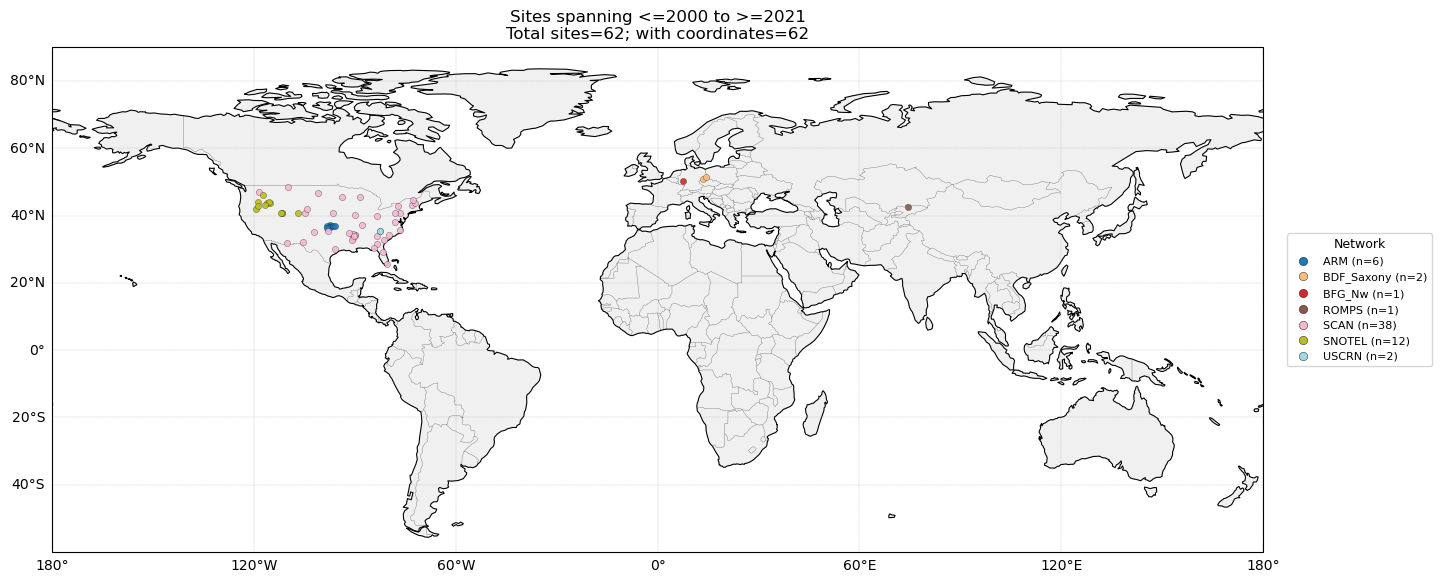

In [38]:
# Plot qualifying-site locations for both criteria (two maps), color-coded by network.
try:
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except Exception as e:
    raise RuntimeError('Cartopy/matplotlib import failed in this kernel. Install cartopy and retry.') from e

def _rows_with_coords(rows):
    return [
        r for r in rows
        if r.get('latitude') is not None and r.get('longitude') is not None
    ]

def _network_color_map(networks):
    nets = sorted(networks)
    if len(nets) <= 20:
        cmap = plt.cm.get_cmap('tab20', len(nets))
    else:
        cmap = plt.cm.get_cmap('gist_ncar', len(nets))
    return {net: cmap(i) for i, net in enumerate(nets)}

def plot_sites_map_by_network(rows, title):
    rows_with_coords = _rows_with_coords(rows)

    fig = plt.figure(figsize=(14.5, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    # Crop map to 60S since there are no ISMN soil-moisture sites in Antarctica.
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='0.94')
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)

    if rows_with_coords:
        networks = {r['network'] for r in rows_with_coords}
        color_map = _network_color_map(networks)

        rows_by_network = {}
        for r in rows_with_coords:
            rows_by_network.setdefault(r['network'], []).append(r)

        legend_handles = []
        for net in sorted(rows_by_network):
            net_rows = rows_by_network[net]
            lons = [r['longitude'] for r in net_rows]
            lats = [r['latitude'] for r in net_rows]
            color = color_map[net]

            ax.scatter(
                lons,
                lats,
                s=20,
                color=color,
                alpha=0.9,
                edgecolors='black',
                linewidths=0.2,
                transform=ccrs.PlateCarree(),
                zorder=3,
            )

            legend_handles.append(
                Line2D([0], [0], marker='o', color='w', label=f"{net} (n={len(net_rows)})",
                       markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.3,
                       markersize=6)
            )

        ax.legend(
            handles=legend_handles,
            title='Network',
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
            fontsize=8,
            title_fontsize=9,
            borderaxespad=0.0,
        )

    ax.set_title(
        f"{title}\nTotal sites={len(rows):,}; with coordinates={len(rows_with_coords):,}"
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    plt.tight_layout()
    plt.show()

plot_sites_map_by_network(
    qualifying_sites,
    'Sites spanning <=2008 to >=2021',
)

plot_sites_map_by_network(
    qualifying_sites_2000,
    'Sites spanning <=2000 to >=2021',
)
